In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "Age": np.random.randint(18, 60, n),
    "Height_cm": np.random.randint(150, 200, n),
    "Weight_kg": np.random.randint(50, 110, n),
    "Workout_Hours_per_Week": np.random.randint(0, 10, n),
    "Calories_Intake": np.random.randint(1800, 3500, n),
}

df = pd.DataFrame(data)

# Create a target variable (Fitness Level)
df["Fitness_Level"] = (
    (df["Workout_Hours_per_Week"] * 2 + df["Calories_Intake"] / 1000 + np.random.randn(n)) > 10
).astype(int)

df.to_csv("Exercise.csv", index=False)

df.head()

,Age,Height_cm,Weight_kg,Workout_Hours_per_Week,Calories_Intake,Fitness_Level
0,56,187,64,0,3245,0
1,46,173,103,0,2563,0
2,32,154,92,3,2537,0
3,25,183,109,8,2605,1
4,38,155,86,5,3129,1


In [2]:
import pandas as pd

df = pd.read_csv("Exercise.csv")

df.head()

,Age,Height_cm,Weight_kg,Workout_Hours_per_Week,Calories_Intake,Fitness_Level
0,56,187,64,0,3245,0
1,46,173,103,0,2563,0
2,32,154,92,3,2537,0
3,25,183,109,8,2605,1
4,38,155,86,5,3129,1


In [3]:
X = df.drop("Fitness_Level", axis=1)
y = df["Fitness_Level"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

print("\nDecision Tree Report:\n", classification_report(y_test, dt_predictions))
print("\nRandom Forest Report:\n", classification_report(y_test, rf_predictions))

Decision Tree Accuracy: 0.925
Random Forest Accuracy: 0.95

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.95      0.90      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40


Random Forest Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       0.95      0.95      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



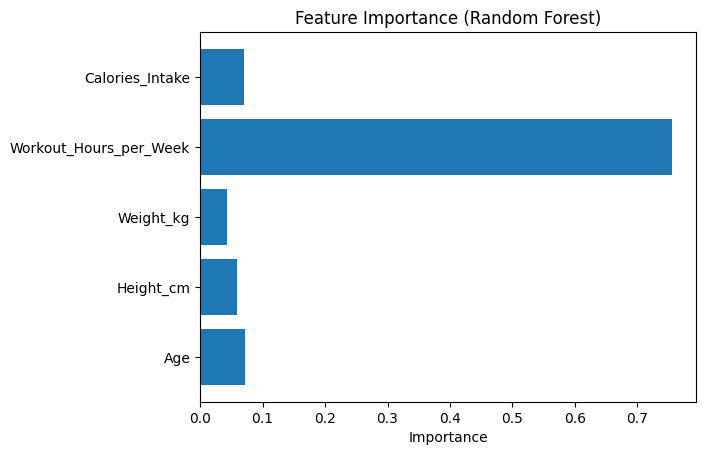

In [8]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()